In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langchain.chat_models import init_chat_model
from typing import List, Optional, TypedDict, Annotated
import operator
from dotenv import load_dotenv
from pydantic import BaseModel, Field

# Load environmental variables from .env
load_dotenv()

True

In [2]:
llm_gpt_mini = init_chat_model("gpt-5-mini")
llm_nano = init_chat_model("gpt-5-nano")
# llm_gemini = init_chat_model("gemini-pro", model_provider="google_genai")


## **Define state and create a graph**

In [3]:
def coalesce(old: Optional[str], new: Optional[str]) -> Optional[str]:
    return new or old

class GState(BaseModel):
    messages: Annotated[list[AnyMessage], operator.add]
    city: Annotated[str, coalesce] = Field(description="City name.", default="")
    interests: Annotated[List[str], operator.add] =  Field(description="Short list of interests - 3-5 elements")
    activities: Annotated[List[str], operator.add] = Field(description="List of activities.")
    sights: Annotated[List[str], operator.add] = Field(description="List of interesting places")

graph = StateGraph(GState)



##**Edges**

In [4]:

def collect_preferences(state: GState) -> GState:

    class RespStructure(BaseModel):
        city: str
        interests: List[str]

    text = state.messages[-1].content if state.messages else ""
    prompt = f"""From the user input (may be empty):
<user_input>
{text}
</user_input>

extract information about the city name and user's interests.
"""
    ai = llm_nano.with_structured_output(RespStructure).invoke(prompt)
    state.city = ai.city
    state.interests = ai.interests
    return state

def ask_activities(state: GState) -> GState:
    prompt = f"User likes {', '.join(state.interests)}. User will visit: {state.city}. Suggest 3 activities."
    out = llm_gpt_mini.invoke(prompt).content.split("\n")
    state.activities = state.activities + [x for x in out if x.strip()]
    return state

def ask_sights(state: GState) -> GState:
    prompt = f"Most interesting places to visit in {state.city}: 3 propositions."
    out = llm_gpt_mini.invoke(prompt).content.split("\n")
    state.sights = state.sights + [x for x in out if x.strip()]
    return state

def compose_answer(state: GState) -> GState:
    answer = (
        f"### City: {state.city}\n"
        f"### Interests: {', '.join(state.interests)}\n"
        f"### Activities:\n- " + "\n- ".join(state.activities) + "\n"
        f"### Locations:\n- " + "\n- ".join(state.sights)
    )
    state.messages = state.messages + [AIMessage(answer)]
    return state



##Create graph layout

In [5]:
graph.add_node("collect_preferences", collect_preferences)
graph.add_node("ask_activities", ask_activities)
graph.add_node("ask_sights", ask_sights)
graph.add_node("compose_answer", compose_answer)

# 4) Krawędzie – najprostszy liniowy przepływ
graph.set_entry_point("collect_preferences")
graph.add_edge("collect_preferences", "ask_activities")
graph.add_edge("collect_preferences", "ask_sights")
graph.add_edge("ask_activities", "compose_answer")
graph.add_edge("ask_sights", "compose_answer")
graph.add_edge("compose_answer", END)

app = graph.compile()




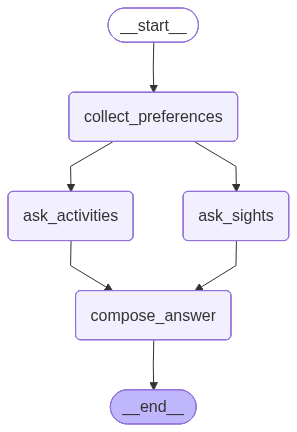

In [6]:
# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [7]:
initial = GState(
    messages = [HumanMessage("I like wild animals and I will visit Łódź.")],
    city = "",
    interests = [],
    activities = [],
    sights = []
)
final_result = app.invoke(initial)
print(final_result["messages"][-1].content)

### City: Łódź
### Interests: wild animals, wild animals, wild animals
### Activities:
- Great — since you like wild animals, here are three things in/near Łódź you’ll enjoy:
- 1) Łódź Zoo (Miejski Ogród Zoologiczny)
- - What: Classic city zoo with a wide range of mammals, birds and reptiles; good for close-up animal viewing and educational talks.
- - Why you’ll like it: Easy way to see many species in one visit; combine with a stroll through the adjacent Łagiewniki area.
- - Tips: Buy tickets online if available, check the zoo’s schedule for feeding/demonstration times, and go early to avoid crowds.
- 2) Łagiewnicki Forest — wildlife walk and birdwatching
- - What: One of Europe’s largest municipal forests right next to the city. Miles of trails, wetlands, and quiet glades.
- - Why you’ll like it: Great for spotting native wildlife (birds, deer traces, fox signs), hearing woodpeckers and owls, and getting a real nature fix close to Łódź.
- - Tips: Bring binoculars and a field guide or